## LSTM  Long Short-Term Memory

The aim of this notebook is to show how to train LSTM on a real synthetic dataset.

### The Training Problem

Given a language grammar, the LSTM will be able to classify sequences of characters as valid or invalid according to the grammar rules.

BNF Definition:

$$
\begin{array}{rcl}
\langle\mathit{string}\rangle   & \mathrel{::=} & \langle\mathit{term}\rangle \\
                              & \mid          & \langle\mathit{string}\rangle \mathbin{\texttt{+}} \langle\mathit{term}\rangle \\[2pt]
\langle\mathit{term}\rangle   & \mathrel{::=} & AB, ED, OK \\[2pt]
\end{array}
$$

## Tokenizer

In order to represent the terms of the language we need to define a tokenizer that will map every letters of the alphabet to point in a vector space.
Our vector space has 3 dimensions:

- Is Vowel
- Is Consonant
- Position in alphabet

so every term will be represented as a 3D vector in this space.

In [9]:
"""Dataset Generation"""

import numpy as np
from examples.recurrent.helpers import generate_invalid_seqs, generate_valid_seqs, tokenize
from thorcino.dataset.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor


SPLIT_RATIO = 0.8
BATCH_SIZE = 16
N_SEQ, LEN_SEQ = 150, 10

X_valid = np.array(tokenize(generate_valid_seqs(N_SEQ, LEN_SEQ)))
X_invalid = np.array(tokenize(generate_invalid_seqs(N_SEQ, LEN_SEQ*2)))

In [10]:
from examples.recurrent.helpers import parse_vect


for seq in X_valid:
    assert parse_vect(seq) == True

for seq in X_invalid:
    assert parse_vect(seq) == False

In [11]:
X = np.append(X_valid, X_invalid, axis=0)
np.random.shuffle(X)

TRAIN_LEN = int(X.shape[0]*SPLIT_RATIO)

Y = [np.array([parse_vect(seq)], dtype=np.float32) for seq in X]
Y = np.array(Y)

X_train, X_test = X[:TRAIN_LEN], X[TRAIN_LEN:]
Y_train, Y_test = Y[:TRAIN_LEN], Y[TRAIN_LEN:]

In [12]:
for seq, is_valid in zip(X, Y):
    assert parse_vect(seq) == is_valid.flatten()[0]

In [13]:
train_dataset, test_dataset = TensorDataset(Tensor(X_train), Tensor(Y_train)), TensorDataset(Tensor(X_test), Tensor(Y_test))
train_dataloader, test_dataloader = DataLoader(train_dataset, BATCH_SIZE, True), DataLoader(test_dataset, BATCH_SIZE, True)

In [14]:
"""Model Architecture"""

from thorcino.activations import Sigmoid
from thorcino.layers.linear import Linear
from thorcino.layers.lstm import LSTM
from thorcino.layers.sequential import Sequential
from thorcino.losses import BinaryCrossEntropyLoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineSchedule
from thorcino.training.trainer import Trainer

EPOCHS, EVAL_STEP = 100, 10
MAX_LR, MIN_LR = 1e-1, 1e-4

model = Sequential(
    LSTM(
        in_feature=3,
        hidden_units=3,
        out_type='n_to_1',
    ),
    Linear(
        in_feature=3,
        out_feature=1,
    ),
    Sigmoid()
)
loss = BinaryCrossEntropyLoss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(
    model,
    loss,
    optimizer,
    scheduler,
)

model.save_arch('./images/arch.png', X_train.shape)

In [15]:
"""Training"""

for e in range(EPOCHS):
    loss = trainer.train_epoch(train_dataloader)

    if e%EVAL_STEP == 0:
        loss, acc = trainer.eval(test_dataloader)

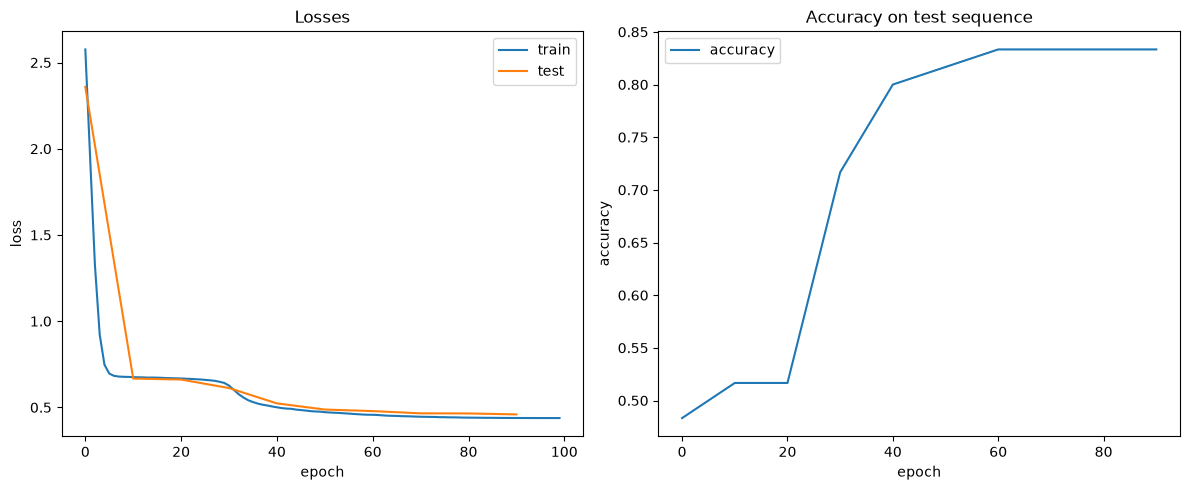

------------------
TRAIN LOSS IMPROVED BY 82.99%
TEST LOSS IMPROVED BY 80.528%
ACCURACY IMPROVED BY 42.0%


In [16]:
"""Plot Metrics"""

import matplotlib.pyplot as plt

from examples.helpers.metrics import diff_percentage

fig, (loss_ax, accuracy_ax) = plt.subplots(1, 2, figsize=(12, 5))

loss_ax.plot(range(EPOCHS), trainer.history['train_loss'], label="train")
loss_ax.plot(range(0, EPOCHS, EVAL_STEP), trainer.history['eval_loss'], label="test")
loss_ax.set_title("Losses")
loss_ax.set_xlabel("epoch")
loss_ax.set_ylabel("loss")
loss_ax.legend()

accuracy_ax.set_title("Accuracy on test sequence")
accuracy_ax.plot(range(0, EPOCHS, EVAL_STEP), trainer.history['accuracy'], label="accuracy")
accuracy_ax.set_xlabel("epoch")
accuracy_ax.set_ylabel("accuracy")
accuracy_ax.legend()

fig.tight_layout()
plt.show()

print('------------------')
print(f'TRAIN LOSS IMPROVED BY {round(diff_percentage(trainer.history['train_loss'][-1], trainer.history['train_loss'][0]), 3)}%')
print(f'TEST LOSS IMPROVED BY {round(diff_percentage(trainer.history['eval_loss'][-1], trainer.history['eval_loss'][0]), 3)}%')
print(f'ACCURACY IMPROVED BY {round(diff_percentage(trainer.history['accuracy'][0], trainer.history['accuracy'][-1]), 3)}%')